# Q1: Supervised Learning - Heart Disease Prediction

This notebook builds and evaluates classification models to predict whether a patient has heart disease.

Target column: `heart_disease`

- `1` = disease present  
- `0` = disease absent

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score

In [17]:
df = pd.read_csv("C:/Users/msoni/Downloads/q1_heart_disease.csv")

df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [18]:
print("Dataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape:
(800, 12)

Data types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


## Data Loading and Inspection

The dataset has been loaded successfully. I checked the number of rows and columns, data types of each column, and missing values. This helps understand whether cleaning or preprocessing is required before model training.

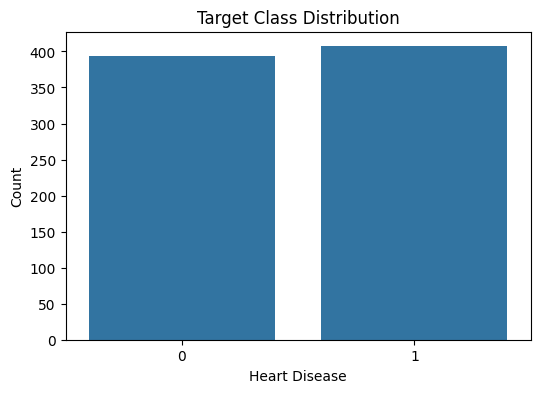

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="heart_disease")
plt.title("Target Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

The target class distribution shows how many patients have heart disease and how many do not. This is important because if one class is much larger than the other, accuracy alone may not be a reliable evaluation metric.

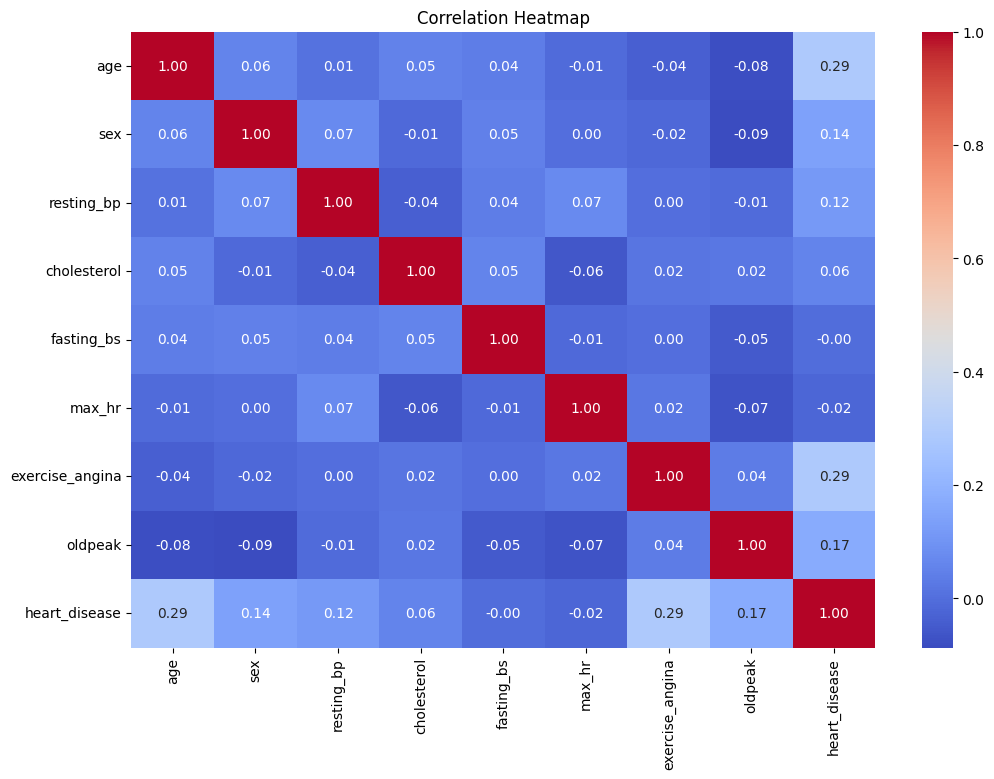

In [20]:
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows relationships between numerical variables. Strong positive or negative correlations can indicate which features may be useful for prediction.

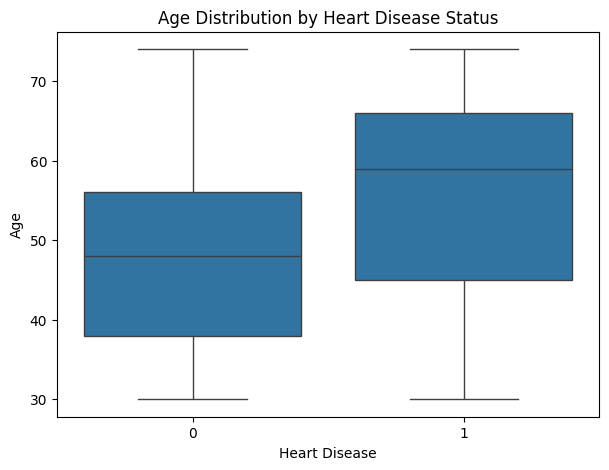

In [21]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="heart_disease", y="age")
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()

This plot compares the age distribution of patients with and without heart disease. It helps identify whether age may be an important factor in predicting heart disease.

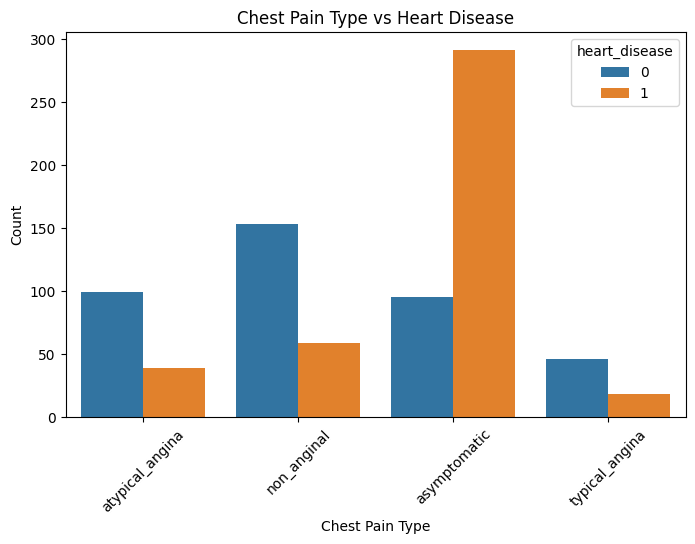

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="chest_pain_type", hue="heart_disease")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

This chart compares chest pain types across patients with and without heart disease. Chest pain type is clinically relevant and may help the model distinguish between the two classes.

In [23]:
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

print("Feature columns:")
print(X.columns)

print("\nTarget column:")
print(y.name)

Feature columns:
Index(['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol',
       'fasting_bs', 'resting_ecg', 'max_hr', 'exercise_angina', 'oldpeak',
       'st_slope'],
      dtype='str')

Target column:
heart_disease


In [24]:
numeric_features = ["age", "resting_bp", "cholesterol", "max_hr", "oldpeak"]

categorical_features = [
    "sex",
    "chest_pain_type",
    "fasting_bs",
    "resting_ecg",
    "exercise_angina",
    "st_slope"
]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (640, 11)
Testing set shape: (160, 11)


In [26]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Data Preprocessing

Missing numerical values are handled using median imputation because the median is less affected by outliers. Missing categorical values are handled using the most frequent value because it is a simple and suitable approach for categorical data.

Categorical variables are converted into numerical format using one-hot encoding. Numerical variables are scaled using StandardScaler so that features with larger values do not dominate the models.

The dataset is split into training and testing sets using stratification to maintain the same target class proportion in both sets.

In [27]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_models = {}

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    clf.fit(X_train, y_train)
    trained_models[name] = clf
    
    print(f"{name} trained successfully.")

Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [28]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })
    
    print("=" * 50)
    print(name)
    print("=" * 50)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Decision Tree
Confusion Matrix:
[[58 21]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74        79
           1       0.75      0.77      0.76        81

    accuracy                           0.75       160
   macro avg       0.75      0.75      0.75       160
weighted avg       0.75      0.75      0.75       160

Random Forest
Confusion Matrix:
[[63 16]
 [17 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.79        79
           1       0.80      0.79      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

Gradient Boosting
Confusion Matrix:
[[61 18]
 [18 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        79
        

In [29]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.75000,0.746988,0.765432,0.756098
1,Random Forest,0.79375,0.800000,0.790123,0.795031
2,Gradient Boosting,0.77500,0.777778,0.777778,0.777778


In [30]:
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]
best_model_name

'Random Forest'

## Model Evaluation Summary

The models were compared using accuracy, precision, recall, and F1-score. For this heart disease prediction problem, F1-score is especially useful because it balances precision and recall.

The best-performing model is Random Forest because it achieved the highest F1-score among the three models. It also provides a good balance between precision and recall, making it more reliable than judging only by accuracy.

In [31]:
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]

if best_model_name == "Decision Tree":
    best_model = DecisionTreeClassifier(random_state=42)
    param_grid = {
        "model__max_depth": [3, 5, 10, None],
        "model__min_samples_split": [2, 5, 10]
    }

elif best_model_name == "Random Forest":
    best_model = RandomForestClassifier(random_state=42)
    param_grid = {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [3, 5, 10, None]
    }

else:
    best_model = GradientBoostingClassifier(random_state=42)
    param_grid = {
        "model__n_estimators": [50, 100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 5]
    }

tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best model selected:", best_model_name)
print("Best parameters:")
print(grid_search.best_params_)

Best model selected: Random Forest
Best parameters:
{'model__max_depth': None, 'model__n_estimators': 100}


In [32]:
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

print("Tuned Model Performance")
print("=" * 50)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Accuracy:", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall:", tuned_recall)
print("F1 Score:", tuned_f1)

Tuned Model Performance
Confusion Matrix:
[[63 16]
 [17 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.79        79
           1       0.80      0.79      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

Accuracy: 0.79375
Precision: 0.8
Recall: 0.7901234567901234
F1 Score: 0.7950310559006211


In [33]:
baseline_best = results_df[results_df["Model"] == best_model_name].iloc[0]

comparison_df = pd.DataFrame({
    "Model": ["Untuned " + best_model_name, "Tuned " + best_model_name],
    "Accuracy": [baseline_best["Accuracy"], tuned_accuracy],
    "Precision": [baseline_best["Precision"], tuned_precision],
    "Recall": [baseline_best["Recall"], tuned_recall],
    "F1 Score": [baseline_best["F1 Score"], tuned_f1]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Untuned Random Forest,0.79375,0.8,0.790123,0.795031
1,Tuned Random Forest,0.79375,0.8,0.790123,0.795031


## Hyperparameter Tuning Summary

GridSearchCV was used to tune the best-performing model, which was the Random Forest Classifier.

After tuning, the model performance remained the same as the untuned Random Forest model. Both models achieved:

- Accuracy: 0.79375
- Precision: 0.80000
- Recall: 0.790123
- F1-score: 0.795031

Since hyperparameter tuning did not improve the model performance, the untuned Random Forest model can be considered equally effective. In this case, the simpler untuned model may be preferred because it gives the same results without additional tuning complexity.